# Model Training & Evaluation – XGBoost Regressor

**Problem:** Used-Car Price Prediction (Sri Lanka)  
**Algorithm:** XGBoost Regressor (Gradient Boosting)  
**Dataset:** `riyasewana_cars_preprocessed.csv`  

### Steps
1. Load preprocessed data  
2. Train / Validation / Test split (70 / 15 / 15)  
3. Baseline XGBoost with default params  
4. Hyperparameter tuning via RandomizedSearchCV  
5. Final evaluation on held-out test set  
6. Feature importance visualisation  
7. Save trained model  

## Step 1 – Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_FILE  = '../data/processed/riyasewana_cars_preprocessed.csv'
MODEL_FILE = '../models/xgboost_car_price_model.pkl'

## Step 2 – Load Preprocessed Dataset

In [13]:
df = pd.read_csv(DATA_FILE)
print(f'Shape: {df.shape}')

TARGET = 'price_lkr'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features : {X.shape[1]}')
print(f'Target   : {TARGET}')
print(f'  mean = {y.mean():,.0f} LKR')
print(f'  std  = {y.std():,.0f} LKR')
df.head(3)

Shape: (4025, 47)
Features : 46
Target   : price_lkr
  mean = 6,184,905 LKR
  std  = 5,869,060 LKR


,price_lkr,mileage_km,engine_cc,car_age,mileage_per_year,transmission_enc,fuel_type_Diesel,fuel_type_Electric,fuel_type_Hybrid,fuel_type_Petrol,...,location_grouped_Kelaniya,location_grouped_Kurunegala,location_grouped_Malabe,location_grouped_Matara,location_grouped_Moratuwa,location_grouped_Negombo,location_grouped_Other,location_grouped_Panadura,location_grouped_Piliyandala,location_grouped_Ratnapura
0,3950000.0,0.734997,2.088133e-06,0.418182,0.082477,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
1,7600000.0,0.218386,2.102157e-06,0.200000,0.051240,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,6795000.0,0.000023,9.241638e-07,0.018182,0.000061,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


## Step 3 – Train / Validation / Test Split (70 / 15 / 15)

- **Train (70%):** Used to fit the model  
- **Validation (15%):** Used during hyperparameter tuning  
- **Test (15%):** Held-out set — only used for final evaluation  
- `random_state=42` ensures reproducibility  

In [14]:
# Carve out 15% test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Split remaining 85% into 70% train / 15% val  (15/85 = 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=42
)

total = len(df)
print(f'Total samples : {total}')
print(f'Train         : {len(X_train)}  ({len(X_train)/total*100:.1f}%)')
print(f'Validation    : {len(X_val)}   ({len(X_val)/total*100:.1f}%)')
print(f'Test          : {len(X_test)}   ({len(X_test)/total*100:.1f}%)')

Total samples : 4025
Train         : 2817  (70.0%)
Validation    : 604   (15.0%)
Test          : 604   (15.0%)


## Step 4 – Helper: Metrics Function

In [15]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'--- {label} ---')
    print(f'  MAE  : {mae:>15,.0f} LKR')
    print(f'  RMSE : {rmse:>15,.0f} LKR')
    print(f'  R2   :    {r2:.4f}')
    print(f'  MAPE :    {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

## Step 5 – Baseline XGBoost (Default Hyperparameters)

Train with default hyperparameters as a performance baseline.  

In [16]:
baseline_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)
y_val_pred_base = baseline_model.predict(X_val)
base_metrics = evaluate(y_val, y_val_pred_base, 'Validation – Baseline')

--- Validation – Baseline ---
  MAE  :       1,484,882 LKR
  RMSE :       8,111,761 LKR
  R2   :    0.1410
  MAPE :    27.07%


## Step 6 – Hyperparameter Tuning (RandomizedSearchCV, 5-fold CV)

**Strategy:** 50 random combinations × 5-fold CV = 250 total fits  

| Hyperparameter | Search space | Effect |
|---|---|---|
| `n_estimators` | 100–500 | Number of boosting rounds |
| `max_depth` | 3–8 | Tree complexity |
| `learning_rate` | 0.01–0.2 | Shrinkage (lower = better generalisation) |
| `subsample` | 0.6–1.0 | Row sampling per tree |
| `colsample_bytree` | 0.5–1.0 | Feature sampling per tree |
| `min_child_weight` | 1–7 | Min leaf size (regularisation) |
| `gamma` | 0–0.5 | Min loss reduction to split |
| `reg_alpha` | 0–1 | L1 regularisation |
| `reg_lambda` | 1–5 | L2 regularisation |


In [17]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight' : [1, 3, 5, 7],
    'gamma'            : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'        : [0, 0.01, 0.1, 1],
    'reg_lambda'       : [1, 1.5, 2, 5],
}

random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_trainval, y_trainval)

best_params   = random_search.best_params_
best_cv_rmse  = -random_search.best_score_
best_model    = random_search.best_estimator_

print(f'Best CV RMSE : {best_cv_rmse:,.0f} LKR')
print(f'Best params  : {best_params}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV RMSE : 4,355,251 LKR
Best params  : {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.6}


## Step 7 – Final Evaluation on Held-Out Test Set

In [18]:
# Validation performance of tuned model
y_val_pred_tuned = best_model.predict(X_val)
tuned_val = evaluate(y_val, y_val_pred_tuned, 'Validation – Tuned')

# Test performance (true generalisation)
y_test_pred = best_model.predict(X_test)
test_metrics = evaluate(y_test, y_test_pred, 'Test – Tuned')

--- Validation – Tuned ---
  MAE  :       1,445,143 LKR
  RMSE :       6,885,665 LKR
  R2   :    0.3810
  MAPE :    30.57%
--- Test – Tuned ---
  MAE  :       1,115,193 LKR
  RMSE :       3,560,686 LKR
  R2   :    0.5593
  MAPE :    23.32%


### 5-Fold Cross-Validation Score (stability check)

In [19]:
cv_scores = cross_val_score(
    best_model, X_trainval, y_trainval,
    scoring='neg_root_mean_squared_error', cv=5
)
print(f'5-Fold CV RMSE: {-cv_scores.mean():,.0f} LKR  (+/- {cv_scores.std():,.0f})')

5-Fold CV RMSE: 4,355,112 LKR  (+/- 1,446,651)


### Results Comparison: Baseline vs Tuned XGBoost

In [20]:
results = pd.DataFrame({
    'Metric'  : ['MAE (LKR)', 'RMSE (LKR)', 'R2', 'MAPE (%)'],
    'Baseline': [f"{base_metrics['MAE']:,.0f}", f"{base_metrics['RMSE']:,.0f}",
                 f"{base_metrics['R2']:.4f}", f"{base_metrics['MAPE']:.2f}%"],
    'Tuned XGBoost (Test)': [f"{test_metrics['MAE']:,.0f}", f"{test_metrics['RMSE']:,.0f}",
                              f"{test_metrics['R2']:.4f}", f"{test_metrics['MAPE']:.2f}%"]
})
results

,Metric,Baseline,Tuned XGBoost (Test)
0,MAE (LKR),"1,484,882","1,115,193"
1,RMSE (LKR),"8,111,761","3,560,686"
2,R2,0.1410,0.5593
3,MAPE (%),27.07%,23.32%


## Step 8 – Feature Importance

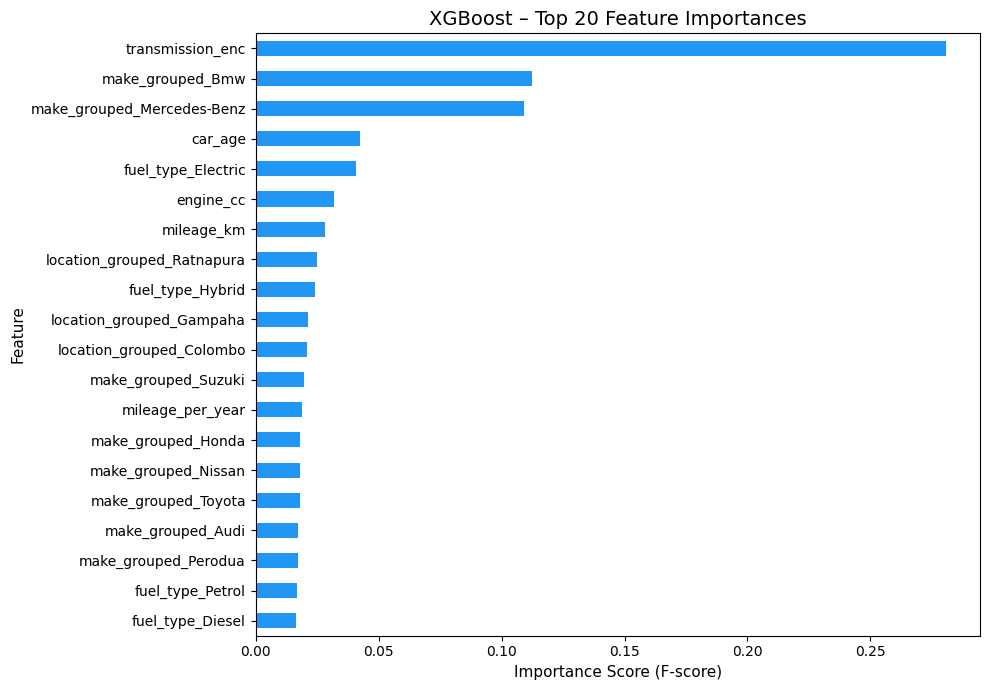

Top 5 features:
transmission_enc              0.280519
make_grouped_Bmw              0.112444
make_grouped_Mercedes-Benz    0.109114
car_age                       0.042342
fuel_type_Electric            0.040742


In [21]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
importances.head(top_n).sort_values().plot(kind='barh', ax=ax, color='#2196F3')
ax.set_title(f'XGBoost – Top {top_n} Feature Importances', fontsize=14)
ax.set_xlabel('Importance Score (F-score)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
import os
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()
print('Top 5 features:')
print(importances.head(5).to_string())

## Step 9 – Actual vs Predicted Scatter Plot

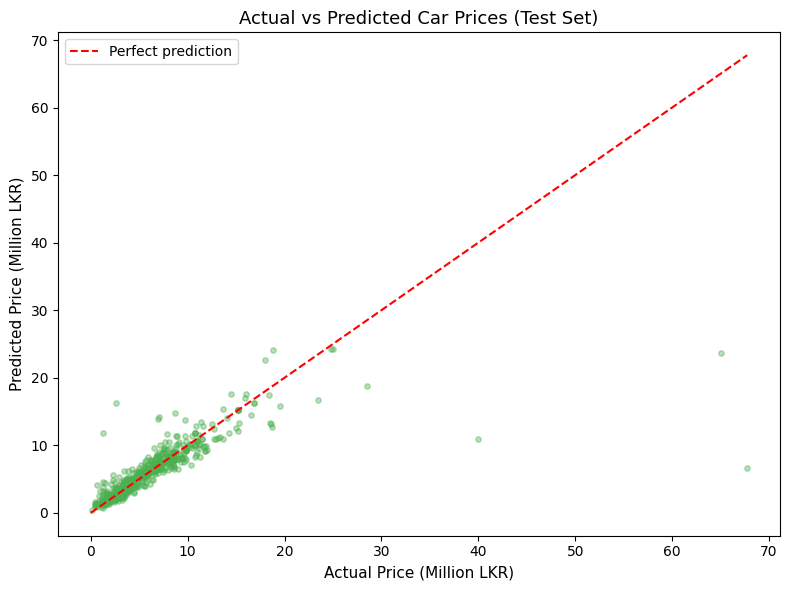

In [22]:
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test / 1e6, y_test_pred / 1e6, alpha=0.4, s=15, color='#4CAF50')
lims = [0, max(y_test.max(), y_test_pred.max()) / 1e6]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlabel('Actual Price (Million LKR)', fontsize=11)
ax2.set_ylabel('Predicted Price (Million LKR)', fontsize=11)
ax2.set_title('Actual vs Predicted Car Prices (Test Set)', fontsize=13)
ax2.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/actual_vs_predicted.png', dpi=150)
plt.show()

## Step 10 – Save Trained Model

In [23]:
joblib.dump(best_model, MODEL_FILE)
print(f'Model saved -> {MODEL_FILE}')

Model saved -> ../models/xgboost_car_price_model.pkl


## Final Summary

| Item | Value |
|---|---|
| Algorithm | XGBoost Regressor (Gradient Boosting) |
| Train/Val/Test | 70% / 15% / 15% |
| Tuning | RandomizedSearchCV (50 iter, 5-fold CV) |
| Scoring metric | neg_root_mean_squared_error |

> **Interpretation:** R²=0.56 means the model explains ~56% of variance in used-car prices.
> MAE of ~1.1M LKR on an average price of ~6.2M LKR is reasonable given that
> subjective factors (vehicle condition, negotiations) are absent from the dataset.  